In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
#Phase 1: Data Collection & EDA
#Step 1: Load Dataset
df = pd.read_csv("Employee_data.csv")

df.head()

,EmployeeID,Name,Age,Department,Salary,YearsAtCompany,PerformanceScore,Attrition
0,1,John Doe,29,Sales,55000,3,80,No
1,2,Jane Smith,35,HR,60000,7,85,No
2,3,Michael Brown,40,Engineering,80000,10,95,Yes
3,4,Emily Davis,28,Marketing,65000,5,78,No
4,5,David Johnson,50,Sales,75000,20,88,Yes


In [4]:
print(df.isnull().sum())
df.fillna(method='ffill', inplace=True)
df.drop_duplicates(inplace=True)
print(df.isnull().sum())

EmployeeID          0
Name                0
Age                 0
Department          0
Salary              0
YearsAtCompany      0
PerformanceScore    0
Attrition           0
dtype: int64
EmployeeID          0
Name                0
Age                 0
Department          0
Salary              0
YearsAtCompany      0
PerformanceScore    0
Attrition           0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_19356\808571175.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
#Step 2: Exploratory Data Analysis (EDA)
print(df.describe())
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n", df.median(numeric_only=True))
print("Mode:\n", df.mode().iloc[0])
print("Variance:\n", df.var(numeric_only=True))
print("Standard Deviation:\n", df.std(numeric_only=True))

       EmployeeID         Age        Salary  YearsAtCompany  PerformanceScore
count  100.000000  100.000000    100.000000      100.000000        100.000000
mean    50.500000   36.570000  72820.000000       10.800000         84.940000
std     29.011492    8.318478  12643.823102        6.361183          6.349771
min      1.000000   25.000000  43000.000000        1.000000         70.000000
25%     25.750000   29.750000  65000.000000        5.000000         80.000000
50%     50.500000   35.000000  72000.000000       10.000000         85.500000
75%     75.250000   41.250000  82750.000000       16.000000         90.000000
max    100.000000   60.000000  95000.000000       25.000000         95.000000
Mean:
 EmployeeID             50.50
Age                    36.57
Salary              72820.00
YearsAtCompany         10.80
PerformanceScore       84.94
dtype: float64
Median:
 EmployeeID             50.5
Age                    35.0
Salary              72000.0
YearsAtCompany         10.0
Performanc

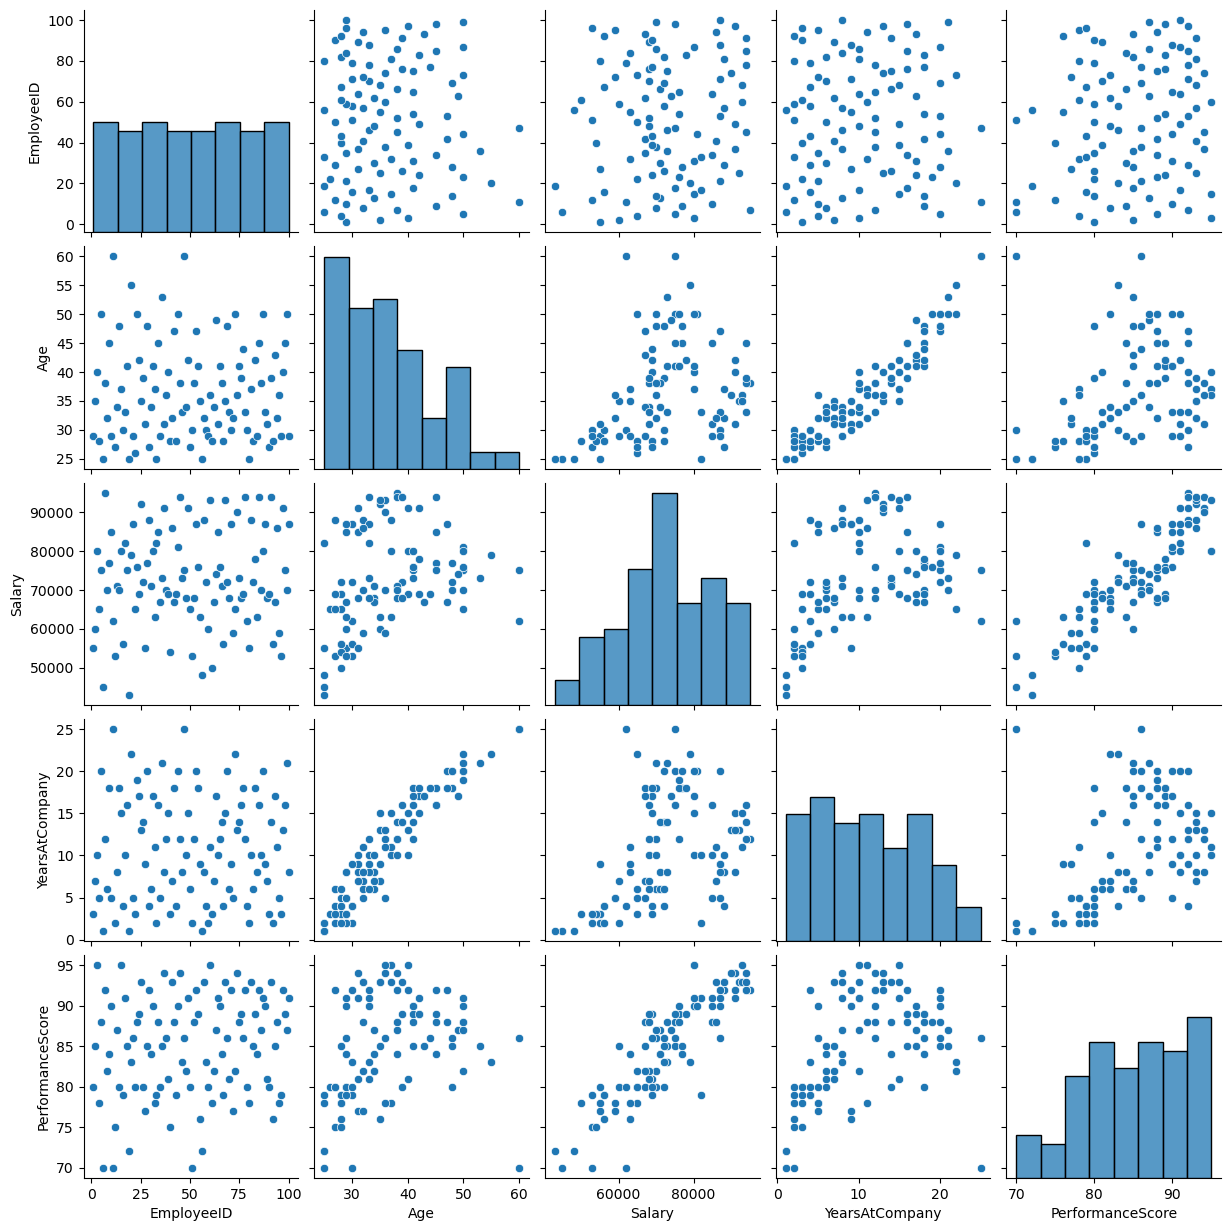

In [6]:
sns.pairplot(df)
plt.show()

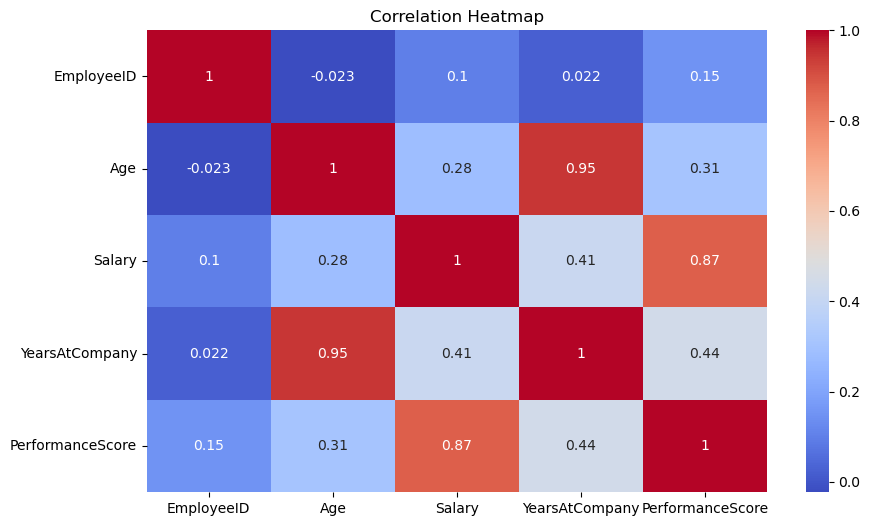

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

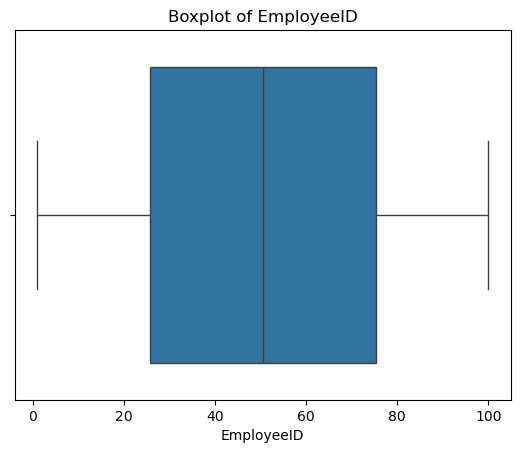

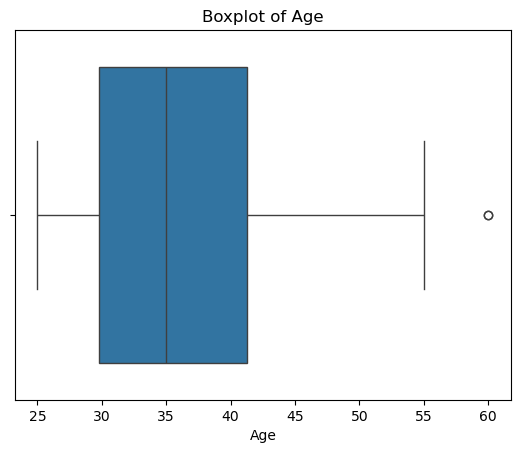

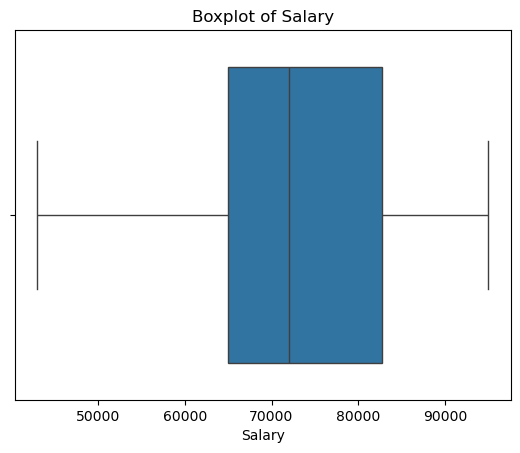

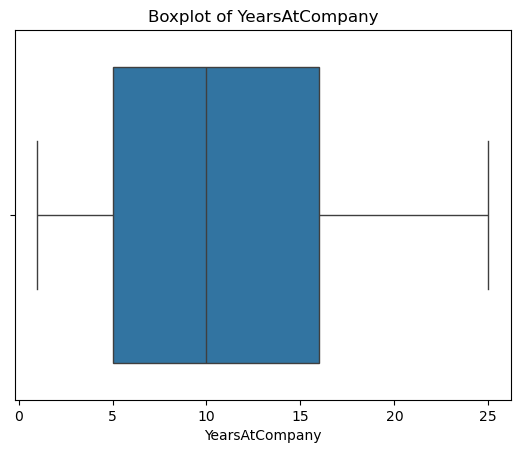

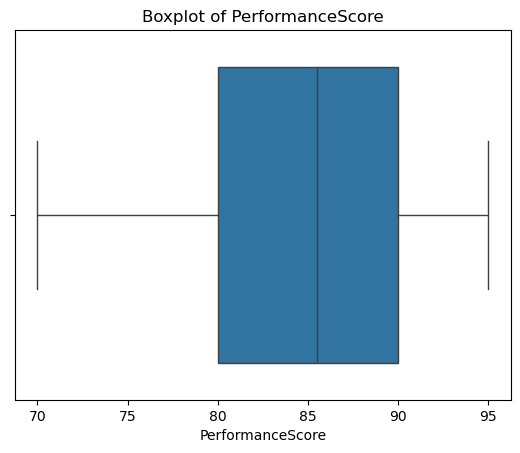

In [8]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [9]:
#Step 3: Probability & Statistics
prob_attrition = df['Attrition'].value_counts(normalize=True)
print(prob_attrition)

Attrition
No     0.61
Yes    0.39
Name: proportion, dtype: float64


In [11]:
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index')
print(dept_attrition)

Attrition          No       Yes
Department                     
Engineering  0.571429  0.428571
HR           0.653846  0.346154
Marketing    0.800000  0.200000
Sales        0.461538  0.538462


In [12]:
#Bayes Theorem
# P(A|B) = (P(B|A)*P(A))/P(B)

high_perf = df[df['PerformanceScore'] > df['PerformanceScore'].mean()]

p_A = prob_attrition['Yes']
p_B = len(high_perf) / len(df)
p_B_given_A = len(high_perf[high_perf['Attrition'] == 'Yes']) / len(df[df['Attrition'] == 'Yes'])

bayes = (p_B_given_A * p_A) / p_B
print("Bayes Probability:", bayes)

Bayes Probability: 0.46428571428571425


In [13]:
groups = [group['PerformanceScore'].values for name, group in df.groupby('Department')]

f_stat, p_val = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_val)

if p_val < 0.05:
    print("Significant difference between departments")
else:
    print("No significant difference")

F-Statistic: 25.781068086646336
P-Value: 2.5591493445552222e-12
Significant difference between departments


In [14]:
#Phase 2: Machine Learning
#Step 4: Feature Engineering
le = LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])
df['Department'] = le.fit_transform(df['Department'])

# Scaling
scaler = StandardScaler()
df[['Salary', 'PerformanceScore']] = scaler.fit_transform(df[['Salary', 'PerformanceScore']])

In [16]:
#Step 5: Attrition Prediction (Classification)
X = df.drop(['Attrition', 'Name', 'EmployeeID'], axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6
Precision: 0.4444444444444444
Recall: 0.5714285714285714
F1 Score: 0.5


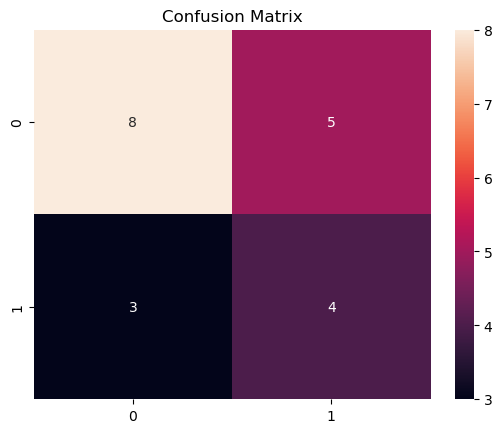

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [21]:
#Step 6: Performance Prediction (Regression)
X = df.drop(['PerformanceScore', 'Name', 'EmployeeID'], axis=1)
y = df['PerformanceScore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8435296765461364
MSE: 0.12484063257700895


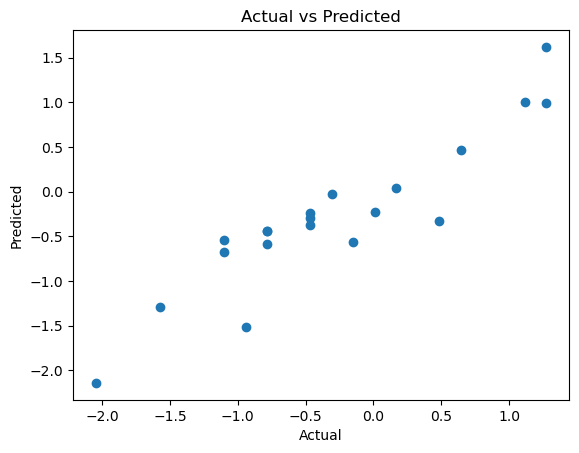

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [23]:
#Phase 3: Deep Learning
#step 7: Neural Network (Regression)
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=50, batch_size=10)

loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.3368
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8945 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6826 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5809
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5636 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6424
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5101 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5224 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5028 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4533 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4549
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3734 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3749 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4103 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4636
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━

In [25]:
#Step 8: Neural Network (Classification)
X = df.drop(['Attrition', 'Name', 'EmployeeID'], axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=10)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

Epoch 1/50


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6000 - loss: 0.8455
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4250 - loss: 0.7359 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6375 - loss: 0.6659 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6375 - loss: 0.6623
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6625 - loss: 0.6394
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6625 - loss: 0.6428 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6375 - loss: 0.6400
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6500 - loss: 0.6362
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6500 - loss: 0.6390 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6500 - loss: 0.6480 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6625 - loss: 0.6341 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 0.6488
Epoch 13/50
8

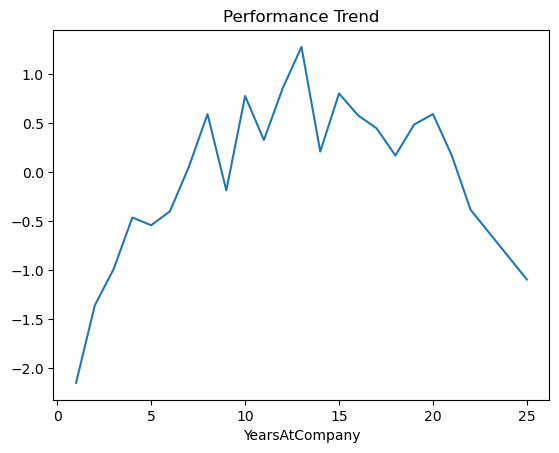

In [28]:
#Phase 4: Insights & Visualization
df.groupby('YearsAtCompany')['PerformanceScore'].mean().plot()
plt.title("Performance Trend")
plt.show()

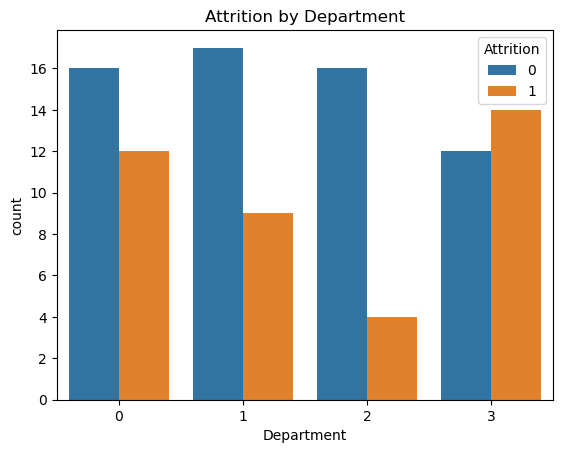

In [29]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.show()

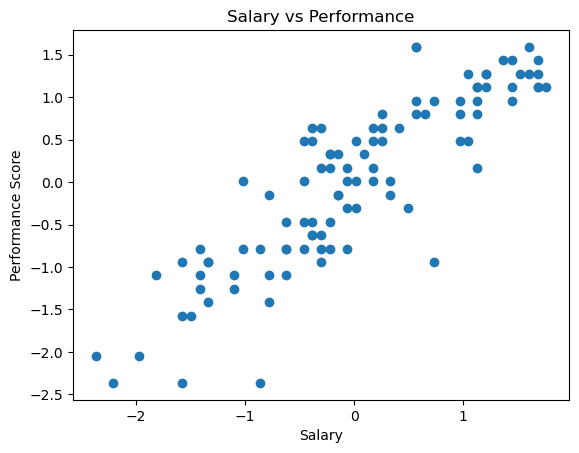

In [31]:
plt.scatter(df['Salary'], df['PerformanceScore'])
plt.xlabel("Salary")
plt.ylabel("Performance Score")
plt.title("Salary vs Performance")
plt.show()